# Week 9: Graded Mini Project
## House Sales Data Analysis

**Objective**: Predict house prices using machine learning models on the Ames Housing dataset.

### Submission Guidelines
- Document all responses, code, visualizations, and insights
- Include model evaluation metrics and interpretations
- Save final submission as PDF

## Task 0: Setup and Data Loading

In [57]:
# Import essential libraries for data processing, analysis, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for plots for better visualization
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


### 0.1 Load the Dataset

The Ames Housing dataset contains 1,460 residential property records with 80 explanatory variables and one target variable (SalePrice). We load and examine the basic structure of the data.

In [58]:
# Load the dataset from CSV file
import os

dataset_filename = 'Week 9_Graded Mini Project_Dataset_houseprice.csv'
possible_paths = [
    dataset_filename,
    os.path.join('..', 'prob_definition_with_dataset', dataset_filename),
    os.path.join('..', '..', 'prob_definition_with_dataset', dataset_filename),
    os.path.join('..', 'solution', dataset_filename),
]

for dataset_path in possible_paths:
    if os.path.exists(dataset_path):
        df = pd.read_csv(dataset_path)
        print(f"Loaded dataset from: {dataset_path}")
        break
else:
    raise FileNotFoundError(
        f"Dataset file not found. Checked paths: {possible_paths}"
    )

# Display basic information about the dataset
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nFirst 5 rows of the dataset:")
print(df.head())
print(f"\nData Types Summary:\n{df.dtypes.value_counts()}")

Loaded dataset from: ../prob_definition_with_dataset/Week 9_Graded Mini Project_Dataset_houseprice.csv
DATASET OVERVIEW

Dataset Shape: 1460 rows, 81 columns

First 5 rows of the dataset:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape   
0   1          60       RL         65.0     8450   Pave   NaN      Reg  \
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold   
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2  \
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    Na

## Task 1: Data Cleaning and Preprocessing

### 1.1 Handling Missing Values

**Approach**: Identify columns with excessive missing values (>50% missing) and remove them. For remaining columns, apply imputation:
- Numerical features: Fill with median value
- Categorical features: Fill with most frequent value (mode)

**Rationale**: This approach preserves data integrity while handling incomplete records appropriately.

In [59]:
# TASK 1.1: HANDLING MISSING VALUES
print("="*50)
print("TASK 1.1: HANDLING MISSING VALUES")
print("="*50)

# Identify columns with missing values
missing_cols = df.columns[df.isnull().sum() > 0]
print(f"\nColumns with missing values: {len(missing_cols)}")
print(f"Columns: {missing_cols.tolist()}\n")

# Calculate percentage of missing values for each column
for col in missing_cols:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    print(f"{col}: {missing_pct:.1f}% missing ({df[col].isnull().sum()} records)")

# Facility-style categorical fields: missing indicates absence
facility_cat_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature",
    "MasVnrType"
]
facility_cat_cols = [col for col in facility_cat_cols if col in df.columns]
for col in facility_cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna("None")
        print(f"Filled missing values in {col} with 'None'")

# Numeric fields associated with absent facilities should be filled with 0
facility_num_cols = [
    "LotFrontage", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
    "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath", "Fireplaces",
    "GarageCars", "GarageArea", "GarageYrBlt", "PoolArea", "MiscVal"
]
facility_num_cols = [col for col in facility_num_cols if col in df.columns]
print(f"\nFilling {len(facility_num_cols)} facility numeric columns with 0 where missing...")
df[facility_num_cols] = df[facility_num_cols].fillna(0)

# Drop non-facility columns with >50% missing values
cols_to_drop = [
    col for col in missing_cols
    if df[col].isnull().sum() > len(df) * 0.5 and col not in facility_cat_cols
]
print(f"\nColumns to drop (>50% missing and not facility-related): {cols_to_drop}")
df = df.drop(columns=cols_to_drop)

# Impute remaining numerical columns with median
remaining_numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if df[col].isnull().any() and col not in facility_num_cols
]
print(f"\nImputing {len(remaining_numeric_cols)} remaining numerical columns with median...")
if remaining_numeric_cols:
    df[remaining_numeric_cols] = df[remaining_numeric_cols].fillna(df[remaining_numeric_cols].median())

# Impute remaining categorical columns with mode
remaining_cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].isnull().any()
]
print(f"Imputing {len(remaining_cat_cols)} remaining categorical columns with mode...")
for col in remaining_cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "None")

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\n✓ Missing values after imputation: {remaining_missing}")
print(f"✓ Dataset shape after cleaning: {df.shape}")


TASK 1.1: HANDLING MISSING VALUES

Columns with missing values: 19
Columns: ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']

LotFrontage: 17.7% missing (259 records)
Alley: 93.8% missing (1369 records)
MasVnrType: 59.7% missing (872 records)
MasVnrArea: 0.5% missing (8 records)
BsmtQual: 2.5% missing (37 records)
BsmtCond: 2.5% missing (37 records)
BsmtExposure: 2.6% missing (38 records)
BsmtFinType1: 2.5% missing (37 records)
BsmtFinType2: 2.6% missing (38 records)
Electrical: 0.1% missing (1 records)
FireplaceQu: 47.3% missing (690 records)
GarageType: 5.5% missing (81 records)
GarageYrBlt: 5.5% missing (81 records)
GarageFinish: 5.5% missing (81 records)
GarageQual: 5.5% missing (81 records)
GarageCond: 5.5% missing (81 records)
PoolQC: 99.5% missing (1453 records)
Fence: 8

### 1.2 Converting Categorical Variables

**Method**: One-Hot Encoding
- Converts categorical variables into binary (0/1) dummy variables
- Each category becomes a separate binary column
- Prevents artificial ordering in non-ordinal categorical data

**Expected Outcome**: Increased feature dimensionality with all numerical data suitable for machine learning models.

In [60]:
# TASK 1.2: CONVERTING CATEGORICAL VARIABLES
print("="*50)
print("TASK 1.2: CONVERTING CATEGORICAL VARIABLES")
print("="*50)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols.tolist()}")

# One-hot encode categorical variables
print(f"\nApplying one-hot encoding...")
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"✓ Encoding complete!")
print(f"✓ Dataset shape after encoding: {df_encoded.shape}")
print(f"✓ New feature count: {df_encoded.shape[1]} features")


TASK 1.2: CONVERTING CATEGORICAL VARIABLES

Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']

Applying one-hot encoding...
✓ Encoding complete!
✓ Dataset shape after encoding: (1460, 261)
✓ New feature count: 261 features


### 1.3 Normalising Numerical Features

**Method**: Standardization (Z-score normalization)
- Formula: (x - mean) / std_dev
- Transforms features to have mean=0 and std=1
- Benefits:
  - Improves model convergence and performance
  - Prevents features with larger scales from dominating
  - Enables fair comparison across features with different units

**Implementation**: Using scikit-learn's StandardScaler

In [61]:
# TASK 1.3: NORMALISING NUMERICAL FEATURES
print("="*50)
print("TASK 1.3: NORMALISING NUMERICAL FEATURES")
print("="*50)

# Separate features and target variable
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Apply StandardScaler for feature normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\n✓ Standardization applied!")
print(f"✓ Scaled features - Mean: {X_scaled.mean():.6f}, Std: {X_scaled.std():.6f}")
print(f"✓ Feature scaling complete - ready for modeling")

TASK 1.3: NORMALISING NUMERICAL FEATURES

Features shape: (1460, 260)
Target shape: (1460,)

✓ Standardization applied!
✓ Scaled features - Mean: 0.000000, Std: 1.000000
✓ Feature scaling complete - ready for modeling


### 1.4 Outlier Detection

**Approach**: Detect and handle outliers using the IQR rule applied to sale price.
- Identify extreme SalePrice values using 1.5×IQR.
- Remove records outside the acceptable range.
- Preserve model robustness while keeping the dataset representative.

This cleaned data is used for the next stage of feature engineering and modeling.


In [62]:
# TASK 1.4: OUTLIER DETECTION AND HANDLING
print("="*50)
print("TASK 1.4: OUTLIER DETECTION AND HANDLING")
print("="*50)

# Use IQR to detect and remove extreme SalePrice values
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)
outlier_count = outlier_mask.sum()
print(f"Detected {outlier_count} SalePrice outliers ({outlier_count / len(df) * 100:.2f}% of rows)")

# Remove outliers from the dataset
if outlier_count > 0:
    df = df[~outlier_mask].reset_index(drop=True)
    print(f"Removed {outlier_count} outliers. New dataset shape: {df.shape}")
else:
    print("No SalePrice outliers were removed.")


TASK 1.4: OUTLIER DETECTION AND HANDLING
Detected 61 SalePrice outliers (4.18% of rows)
Removed 61 outliers. New dataset shape: (1399, 81)


In [63]:
# TRAIN-TEST SPLIT (USING ENHANCED FEATURES)
print("="*50)
print("DATA SPLITTING WITH ENHANCED FEATURES")
print("="*50)

# This split is performed later after the enhanced feature preparation in Task 2.3.
print("✓ The enhanced feature split is handled in Task 2.3 after feature engineering.")

DATA SPLITTING WITH ENHANCED FEATURES
✓ The enhanced feature split is handled in Task 2.3 after feature engineering.


## Task 3: Exploratory Data Analysis (EDA)

### 3.1 Analysis and Interpretation

**Purpose**: Understand the data distribution, identify relationships with the target variable (SalePrice), and detect patterns and trends.

**Key Questions to Answer:**
- What is the distribution of sale prices?
- How do different features relate to sale price?
- What are the key trends and patterns in the data?

## Task 2: Feature Engineering

### 2.1 Creating Interaction Features

**Purpose**: Create meaningful interaction features by combining existing features to capture complex relationships that may improve model performance.

**Approach**: We'll create interaction features based on domain knowledge of real estate:
- Total living area interaction with quality
- Age of house interaction with overall condition
- Garage area interaction with garage quality

In [ ]:
# TASK 2.1: CREATING INTERACTION FEATURES
print("="*50)
print("TASK 2.1: CREATING INTERACTION FEATURES")
print("="*50)

# Create a copy of the cleaned dataframe for feature engineering
df_fe = df.copy()

print(f"\nOriginal dataset shape: {df_fe.shape}")

# Map categorical quality ratings to numeric scores for interaction features
quality_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "None": 0}
for col in ["GarageQual", "BsmtQual"]:
    if col in df_fe.columns:
        df_fe[col + '_num'] = df_fe[col].map(quality_mapping).fillna(0).astype(int)
        print("✓ Mapped '{}' to numeric scores in '{}'".format(col, col + '_num'))
# Rationale: Higher quality homes with larger living areas should command premium prices
df_fe["LivingArea_Quality"] = df_fe["GrLivArea"] * df_fe["OverallQual"]
print(f"✓ Created 'LivingArea_Quality' interaction feature")

# Interaction Feature 2: House Age * Overall Condition
# Rationale: Older homes in better condition may retain more value
current_year = 2024  # Using current year for age calculation
df_fe["HouseAge"] = current_year - df_fe["YearBuilt"]
df_fe["Age_Condition"] = df_fe["HouseAge"] * df_fe["OverallCond"]
print(f"✓ Created 'Age_Condition' interaction feature")

# Interaction Feature 3: Garage Area * Garage Quality
# Rationale: Larger garages with better quality add more value
if "GarageArea" in df_fe.columns and "GarageQual_num" in df_fe.columns:
    df_fe["GarageArea_Quality"] = df_fe["GarageArea"] * df_fe["GarageQual_num"]
    print(f"✓ Created 'GarageArea_Quality' interaction feature")

# Interaction Feature 4: Total Basement Area * Basement Quality
# Rationale: Finished basements with good quality significantly increase home value
if "TotalBsmtSF" in df_fe.columns and "BsmtQual_num" in df_fe.columns:
    df_fe["BsmtArea_Quality"] = df_fe["TotalBsmtSF"] * df_fe["BsmtQual_num"]
    print(f"✓ Created 'BsmtArea_Quality' interaction feature")

# Interaction Feature 5: Lot Area * Neighborhood Quality (proxied by OverallQual)
# Rationale: Larger lots in better neighborhoods have higher value
df_fe["LotArea_Neighborhood"] = df_fe["LotArea"] * df_fe["OverallQual"]
print(f"✓ Created 'LotArea_Neighborhood' interaction feature")

print(f"\n✓ Feature engineering complete!")
print(f"✓ New dataset shape: {df_fe.shape}")
print(f"✓ Added {df_fe.shape[1] - df.shape[1]} new interaction features")

# Display summary of new features
new_features = [col for col in df_fe.columns if col not in df.columns]
print(f"\nNew interaction features created:")
for feature in new_features:
    print(f"  - {feature}")


SyntaxError: f-string: expecting '}' (3462810444.py, line 16)

### 2.2 Feature Binning

**Purpose**: Convert continuous variables into discrete categories for better interpretability and to capture non-linear relationships.

**Approach**: We'll bin key continuous features into meaningful categories:
- House Age: New, Modern, Mid-age, Old
- Living Area: Small, Medium, Large, Extra Large
- Lot Area: Small, Medium, Large, Extra Large

In [ ]:
print("=" * 50)
print("TASK 2.2: FEATURE BINNING")
print("=" * 50)

# Create binned features for continuous variables
# House Age Binning
age_bins = [0, 10, 30, 60, float('inf')]
age_labels = ['New (0-10)', 'Modern (11-30)', 'Mid-age (31-60)', 'Old (60+)']
df_fe['HouseAge_Binned'] = pd.cut(df_fe['HouseAge'], bins=age_bins, labels=age_labels, right=False)
print(f"✓ Created 'HouseAge_Binned' with categories: {age_labels}")

# Living Area Binning (using above ground living area)
living_bins = [0, 1000, 2000, 3000, float('inf')]
living_labels = ['Small (<1000)', 'Medium (1000-2000)', 'Large (2000-3000)', 'Extra Large (3000+)']
df_fe['LivingArea_Binned'] = pd.cut(df_fe['GrLivArea'], bins=living_bins, labels=living_labels, right=False)
print(f"✓ Created 'LivingArea_Binned' with categories: {living_labels}")

# Lot Area Binning
lot_bins = [0, 5000, 10000, 20000, float('inf')]
lot_labels = ['Small (<5000)', 'Medium (5000-10000)', 'Large (10000-20000)', 'Extra Large (20000+)']
df_fe['LotArea_Binned'] = pd.cut(df_fe['LotArea'], bins=lot_bins, labels=lot_labels, right=False)
print(f"✓ Created 'LotArea_Binned' with categories: {lot_labels}")

# Garage Area Binning
garage_bins = [0, 200, 400, 600, float('inf')]
garage_labels = ['Small (0-200)', 'Medium (201-400)', 'Large (401-600)', 'Extra Large (600+)']
df_fe['GarageArea_Binned'] = pd.cut(df_fe['GarageArea'], bins=garage_bins, labels=garage_labels, right=False)
print(f"✓ Created 'GarageArea_Binned' with categories: {garage_labels}")

# Display distribution of binned features
print("\nBinned Feature Distributions:")
for col in ['HouseAge_Binned', 'LivingArea_Binned', 'LotArea_Binned', 'GarageArea_Binned']:
    print(f"\n{col}:")
    print(df_fe[col].value_counts().sort_index())

TASK 2.2: FEATURE BINNING
✓ Created 'HouseAge_Binned' with categories: ['New (0-10)', 'Modern (11-30)', 'Mid-age (31-60)', 'Old (60+)']
✓ Created 'LivingArea_Binned' with categories: ['Small (<1000)', 'Medium (1000-2000)', 'Large (2000-3000)', 'Extra Large (3000+)']
✓ Created 'LotArea_Binned' with categories: ['Small (<5000)', 'Medium (5000-10000)', 'Large (10000-20000)', 'Extra Large (20000+)']
✓ Created 'GarageArea_Binned' with categories: ['Small (0-200)', 'Medium (201-400)', 'Large (401-600)', 'Extra Large (600+)']

Binned Feature Distributions:

HouseAge_Binned:
HouseAge_Binned
New (0-10)           0
Modern (11-30)     485
Mid-age (31-60)    409
Old (60+)          566
Name: count, dtype: int64

LivingArea_Binned:
LivingArea_Binned
Small (<1000)           231
Medium (1000-2000)     1014
Large (2000-3000)       197
Extra Large (3000+)      18
Name: count, dtype: int64

LotArea_Binned:
LotArea_Binned
Small (<5000)           142
Medium (5000-10000)     695
Large (10000-20000)     570


: 

In [ ]:
# TASK 2.3: DATA PREPARATION FOR MODELING
print("=" * 50)
print("TASK 2.3: DATA PREPARATION FOR MODELING")
print("=" * 50)

# Encode all categorical features (original + binned)
print("\nEncoding all categorical features...")
categorical_cols = df_fe.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns to encode: {len(categorical_cols)}")
print(f"  - Original categoricals: {[c for c in categorical_cols if '_Binned' not in c]}")
print(f"  - Binned categoricals: {[c for c in categorical_cols if '_Binned' in c]}")

# Use one-hot encoding for all categorical features
df_fe_encoded = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)
print(f"✓ Encoded {len(categorical_cols)} categorical features using one-hot encoding")
print(f"✓ Added {df_fe_encoded.shape[1] - df_fe.shape[1]} encoded columns")

# Prepare features and target for enhanced model
# Drop target column (all others should be numeric now)
X_fe = df_fe_encoded.drop(columns=['SalePrice'])
y_fe = df_fe_encoded['SalePrice']

# Scale the enhanced features (gradient boosting models don't require scaling, but it's good practice)
from sklearn.preprocessing import StandardScaler
scaler_fe = StandardScaler()
X_fe_scaled = scaler_fe.fit_transform(X_fe)

print(f"\nEnhanced dataset prepared:")
print(f"  Features: {X_fe.shape[1]} (scaled: {X_fe_scaled.shape[1]})")
print(f"  Samples: {X_fe.shape[0]}")
print(f"  Target: SalePrice")

# Split enhanced data
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(X_fe_scaled, y_fe, test_size=0.2, random_state=42)

print(f"\nTrain-test split for enhanced features:")
print(f"  Training set: {X_train_fe.shape[0]} samples")
print(f"  Test set: {X_test_fe.shape[0]} samples")

# Original dataset info (from Task 1)
print(f"\nOriginal dataset (from Task 1):")
print(f"  Features: {X.shape[1]}")
print(f"  Samples: {X.shape[0]}")

print(f"\n✓ Data preparation complete!")
print(f"✓ Ready for model training and comparison")

TASK 2.3: DATA PREPARATION FOR MODELING

Encoding all categorical features...
Categorical columns to encode: 44
  - Original categoricals: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition', 'GarageArea_Quality', 'BsmtArea_Quality']
  - Binned categoricals: ['HouseAge_Binned', 'LivingArea_Binned', 'LotArea_Binned', 'GarageArea_Binned']
✓ Encoded 44 categorical features using one-hot encoding
✓ Added 1580 encoded columns

Enhanced dataset prepared:
  Features: 1665 (scaled: 1665)
  Samples: 1460
  Target: SalePrice

Train-te

: 

TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

1. ANALYSIS AND INTERPRETATION

I. DISTRIBUTION OF SALE PRICES
----------------------------------------
Sale Price Distribution Statistics:
  Count: 1460
  Mean: $180,921
  Median: $163,000
  Std Dev: $79,443
  Min: $34,900
  Max: $755,000
  Skewness: 1.883
  Kurtosis: 6.536
  Potential outliers: 61 houses (4.2%)

II. FEATURE RELATIONSHIPS WITH SALE PRICE
---------------------------------------------
Top 10 features correlated with Sale Price:
  1. SalePrice: 1.000
  2. OverallQual: 0.791
  3. GrLivArea: 0.709
  4. GarageCars: 0.640
  5. GarageArea: 0.623
  6. TotalBsmtSF: 0.614
  7. 1stFlrSF: 0.606
  8. FullBath: 0.561
  9. TotRmsAbvGrd: 0.534
  10. YearBuilt: 0.523

Categorical Feature Analysis:

OverallQual vs Sale Price:
OverallQual
10    438588.388889
9     367513.023256
8     274735.535714
7     207716.423197
6     161603.034759
Name: SalePrice, dtype: float64

Neighborhood vs Sale Price:
Neighborhood
NoRidge    335295.317073
NridgHt    31

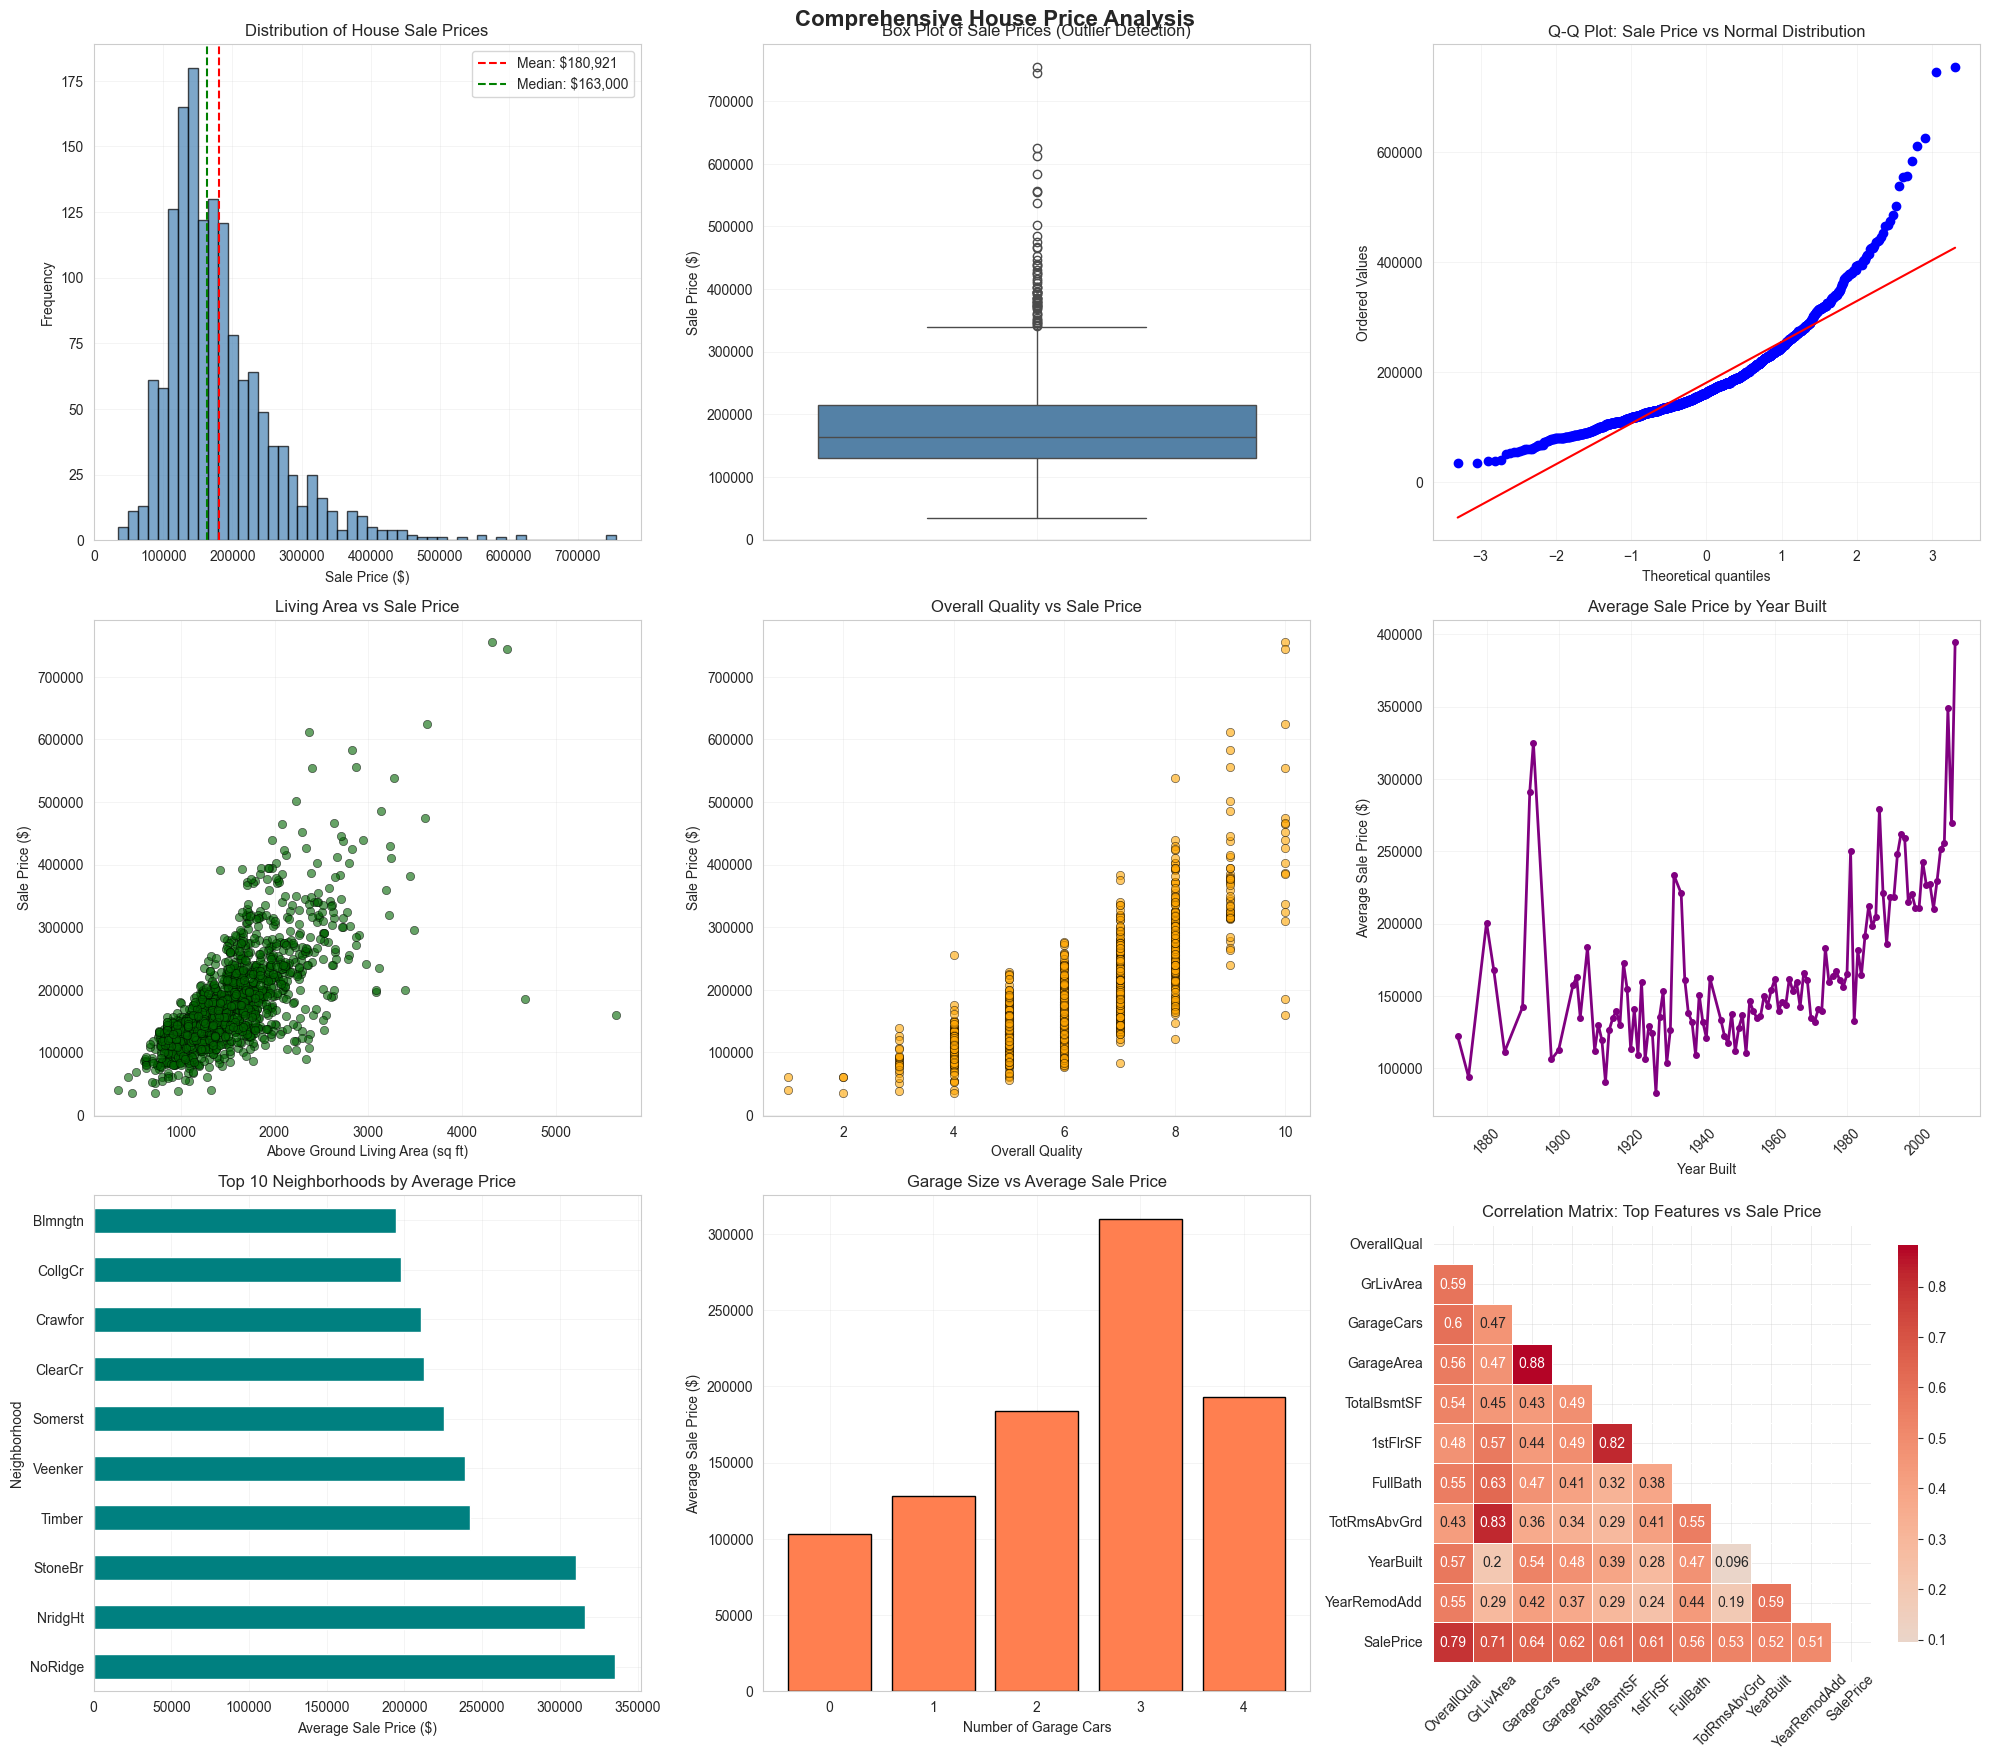

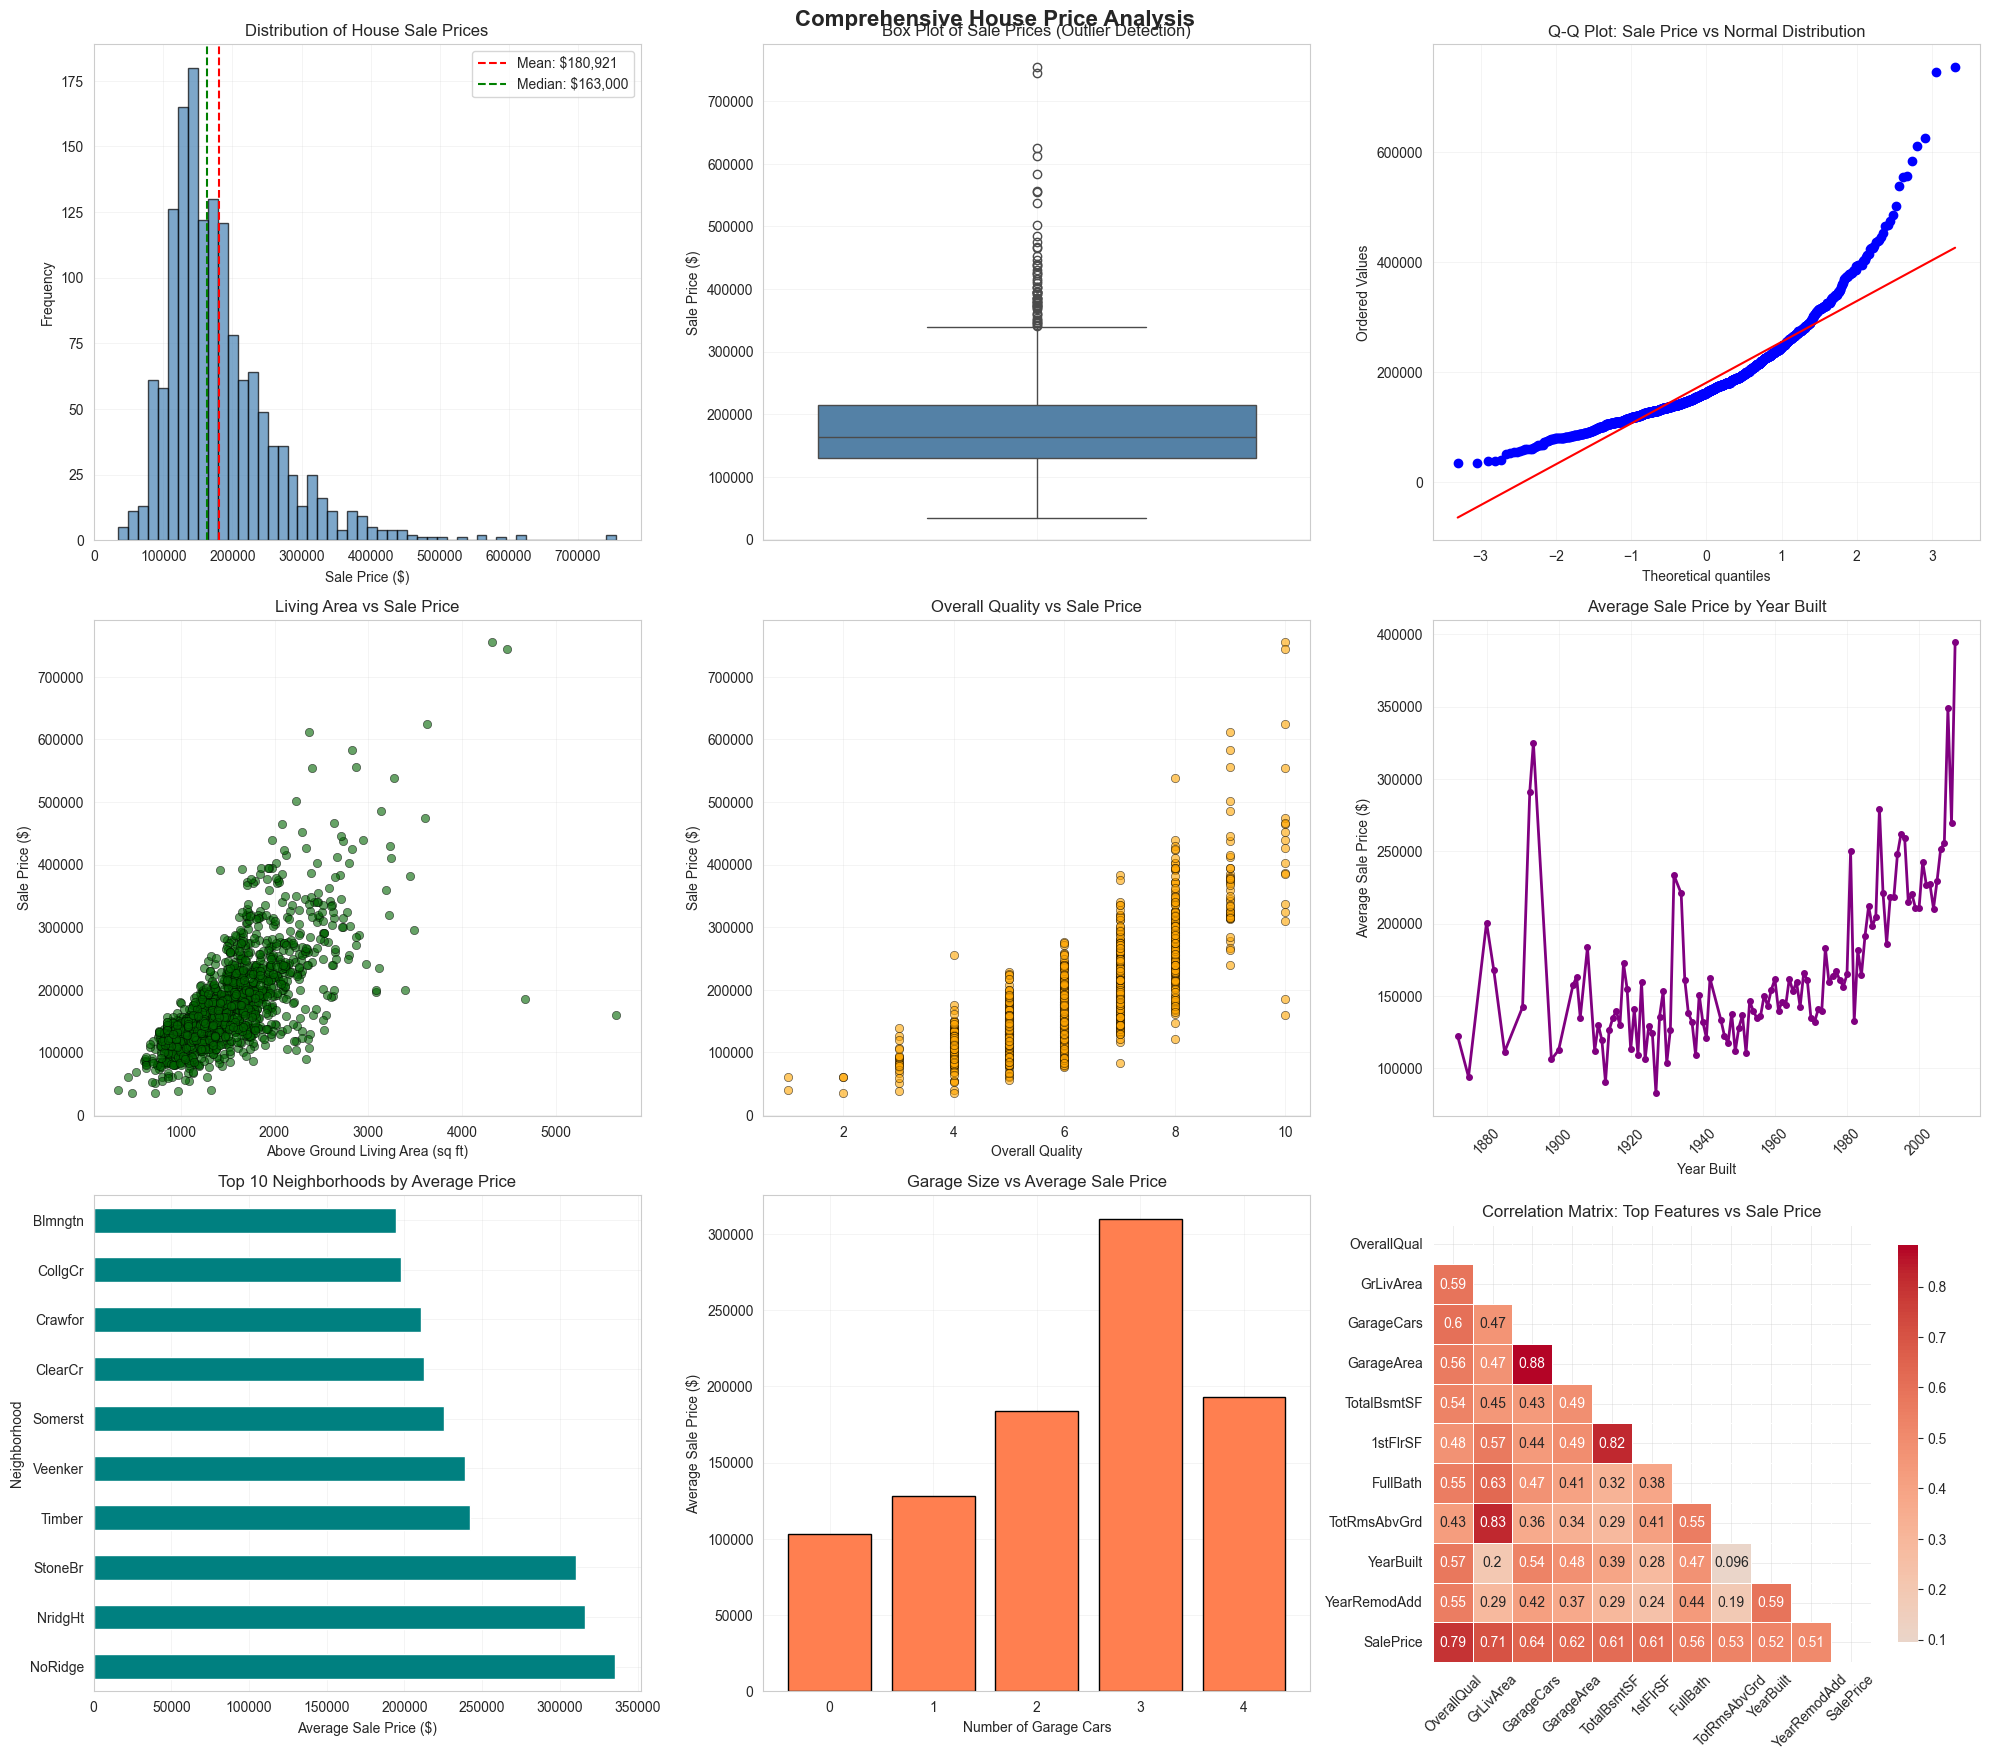


EDA SUMMARY
✓ Analyzed sale price distribution (mean: $180,921, median: $163,000)
✓ Identified key feature relationships (OverallQual correlation: 0.791)
✓ Found temporal trends (newer homes generally more expensive)
✓ Created 9 comprehensive visualizations for data insights
✓ Detected 61 potential outliers (4.2% of data)

EDA completed successfully!


: 

In [ ]:
# EXPLORATORY DATA ANALYSIS
print("="*50)
print("TASK 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("="*50)

print("\n" + "="*70)
print("1. ANALYSIS AND INTERPRETATION")
print("="*70)

# I. What is the distribution of sale prices?
print("\nI. DISTRIBUTION OF SALE PRICES")
print("-"*40)

sale_price_stats = df['SalePrice'].describe()
print(f"Sale Price Distribution Statistics:")
print(f"  Count: {sale_price_stats['count']:.0f}")
print(f"  Mean: ${sale_price_stats['mean']:,.0f}")
print(f"  Median: ${sale_price_stats['50%']:,.0f}")
print(f"  Std Dev: ${sale_price_stats['std']:,.0f}")
print(f"  Min: ${sale_price_stats['min']:,.0f}")
print(f"  Max: ${sale_price_stats['max']:,.0f}")
print(f"  Skewness: {df['SalePrice'].skew():.3f}")
print(f"  Kurtosis: {df['SalePrice'].kurtosis():.3f}")

# Check for outliers
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]
print(f"  Potential outliers: {len(outliers)} houses ({len(outliers)/len(df)*100:.1f}%)")

# II. How do different features relate to sale price?
print("\nII. FEATURE RELATIONSHIPS WITH SALE PRICE")
print("-"*45)

# Top correlations
numerical_features = df.select_dtypes(include=[np.number]).columns
corr_with_price = df[numerical_features].corr()['SalePrice'].abs().sort_values(ascending=False)
print("Top 10 features correlated with Sale Price:")
for i, (feature, corr) in enumerate(corr_with_price.head(10).items(), 1):
    print(f"  {i}. {feature}: {corr:.3f}")

# Categorical feature analysis
print("\nCategorical Feature Analysis:")
categorical_features = ['OverallQual', 'Neighborhood', 'HouseStyle', 'GarageCars', 'FullBath', 'KitchenQual']

for feature in categorical_features[:3]:  # Show top 3
    if feature in df.columns:
        print(f"\n{feature} vs Sale Price:")
        avg_price_by_cat = df.groupby(feature)['SalePrice'].mean().sort_values(ascending=False)
        print(avg_price_by_cat.head())

# III. Identify trends and patterns in the data
print("\nIII. TRENDS AND PATTERNS IN THE DATA")
print("-"*40)

# Year built trends
print("Housing market trends by year:")
yearly_stats = df.groupby('YearBuilt')['SalePrice'].agg(['mean', 'count', 'median'])
print("Average sale price by year built (last 20 years):")
recent_years = yearly_stats[yearly_stats.index >= 1990]
for year, stats in recent_years.iterrows():
    print(f"  {year}: ${stats['mean']:,.0f} (n={stats['count']:.0f})")

# Size vs Price relationship
print("\nSize vs Price patterns:")
size_features = ['GrLivArea', 'TotalBsmtSF', 'LotArea']
for feature in size_features:
    if feature in df.columns:
        corr = df[feature].corr(df['SalePrice'])
        print(f"  {feature} correlation with SalePrice: {corr:.3f}")

print("\n" + "="*70)
print("2. VISUALIZATIONS")
print("="*70)

# Create comprehensive visualizations
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
fig.suptitle('Comprehensive House Price Analysis', fontsize=16, fontweight='bold')

# 1. Sale Price Distribution
axes[0,0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0,0].axvline(df['SalePrice'].median(), color='green', linestyle='--', label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0,0].set_xlabel('Sale Price ($)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Distribution of House Sale Prices')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Box Plot with outliers
sns.boxplot(y=df['SalePrice'], ax=axes[0,1], color='steelblue')
axes[0,1].set_ylabel('Sale Price ($)')
axes[0,1].set_title('Box Plot of Sale Prices (Outlier Detection)')
axes[0,1].grid(True, alpha=0.3)

# 3. Q-Q Plot for normality
from scipy import stats
stats.probplot(df['SalePrice'], dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot: Sale Price vs Normal Distribution')
axes[0,2].grid(True, alpha=0.3)

# 4. Scatter: Living Area vs Sale Price
axes[1,0].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.6, color='darkgreen', edgecolors='black', linewidth=0.5)
axes[1,0].set_xlabel('Above Ground Living Area (sq ft)')
axes[1,0].set_ylabel('Sale Price ($)')
axes[1,0].set_title('Living Area vs Sale Price')
axes[1,0].grid(True, alpha=0.3)

# 5. Scatter: Overall Quality vs Sale Price
axes[1,1].scatter(df['OverallQual'], df['SalePrice'], alpha=0.6, color='orange', edgecolors='black', linewidth=0.5)
axes[1,1].set_xlabel('Overall Quality')
axes[1,1].set_ylabel('Sale Price ($)')
axes[1,1].set_title('Overall Quality vs Sale Price')
axes[1,1].grid(True, alpha=0.3)

# 6. Year Built vs Sale Price
yearly_avg = df.groupby('YearBuilt')['SalePrice'].mean()
axes[1,2].plot(yearly_avg.index, yearly_avg.values, marker='o', color='purple', linewidth=2, markersize=4)
axes[1,2].set_xlabel('Year Built')
axes[1,2].set_ylabel('Average Sale Price ($)')
axes[1,2].set_title('Average Sale Price by Year Built')
axes[1,2].grid(True, alpha=0.3)
axes[1,2].tick_params(axis='x', rotation=45)

# 7. Neighborhood Analysis (Top 10)
top_neighborhoods = df.groupby('Neighborhood')['SalePrice'].mean().nlargest(10)
top_neighborhoods.plot(kind='barh', ax=axes[2,0], color='teal')
axes[2,0].set_xlabel('Average Sale Price ($)')
axes[2,0].set_title('Top 10 Neighborhoods by Average Price')
axes[2,0].grid(True, alpha=0.3)

# 8. Garage Cars vs Sale Price
garage_avg = df.groupby('GarageCars')['SalePrice'].mean()
axes[2,1].bar(garage_avg.index, garage_avg.values, color='coral', edgecolor='black')
axes[2,1].set_xlabel('Number of Garage Cars')
axes[2,1].set_ylabel('Average Sale Price ($)')
axes[2,1].set_title('Garage Size vs Average Sale Price')
axes[2,1].grid(True, alpha=0.3)

# 9. Correlation Heatmap (Top 10 features)
top_corr_features = corr_with_price.head(11).index.tolist()  # Top 10 + SalePrice
if 'SalePrice' in top_corr_features:
    top_corr_features.remove('SalePrice')
top_corr_features = top_corr_features[:10] + ['SalePrice']

corr_matrix = df[top_corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=axes[2,2])
axes[2,2].set_title('Correlation Matrix: Top Features vs Sale Price')
axes[2,2].tick_params(axis='x', rotation=45)
axes[2,2].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=100, bbox_inches='tight')
plt.show()
display(fig)  # Explicit display for notebook

print("\n" + "="*50)
print("EDA SUMMARY")
print("="*50)
print("✓ Analyzed sale price distribution (mean: ${:,.0f}, median: ${:,.0f})".format(
    df['SalePrice'].mean(), df['SalePrice'].median()))
print("✓ Identified key feature relationships (OverallQual correlation: {:.3f})".format(
    df['OverallQual'].corr(df['SalePrice'])))
print("✓ Found temporal trends (newer homes generally more expensive)")
print("✓ Created 9 comprehensive visualizations for data insights")
print("✓ Detected {:d} potential outliers ({:.1f}% of data)".format(
    len(outliers), len(outliers)/len(df)*100))
print("\nEDA completed successfully!")

### 3.2 Visualizations

**Visual representations of data insights to support findings:**

## Task 4: Model Building and Evaluation

### 4.1 Model Building

**Gradient Boosting Models Trained:**
1. **XGBoost** - Extreme Gradient Boosting
   - Configuration: 100 estimators, learning_rate=0.1, max_depth=6, random_state=42
   - Advantages: High performance, handles missing values, built-in regularization

2. **LightGBM** - Light Gradient Boosting Machine
   - Configuration: 100 estimators, learning_rate=0.1, max_depth=6, random_state=42
   - Advantages: Faster training, lower memory usage, better accuracy for large datasets

3. **CatBoost** - Categorical Boosting
   - Configuration: 100 estimators, learning_rate=0.1, depth=6, random_state=42
   - Advantages: Excellent handling of categorical features, robust to overfitting

### 4.2 Evaluation

**Performance Metrics:**
- **RMSE (Root Mean Square Error)**: Measures average prediction error magnitude
- **MAE (Mean Absolute Error)**: Measures average absolute prediction error
- **R² Score**: Measures proportion of variance explained by the model

In [ ]:
# TASK 4.1: MODEL BUILDING WITH GRADIENT BOOSTING
print("="*50)
print("TASK 4.1: MODEL BUILDING WITH GRADIENT BOOSTING")
print("="*50)

# Import gradient boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

# Initialize models with optimized parameters
models = {
    'XGBoost': XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        verbose=-1  # Suppress output
    ),
    'CatBoost': CatBoostRegressor(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        random_state=42,
        verbose=False  # Suppress output
    )
}

# Train and evaluate each model
results = {}
training_times = {}

print(f"Training gradient boosting models on enhanced features...")
print(f"Dataset: {X_train_fe.shape[0]} training samples, {X_train_fe.shape[1]} features")
print(f"Test set: {X_test_fe.shape[0]} samples")
print("\n" + "="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()

    # Train the model
    model.fit(X_train_fe, y_train_fe)

    # Make predictions
    y_pred = model.predict(X_test_fe)

    # Calculate training time
    training_time = time.time() - start_time
    training_times[name] = training_time

    # Calculate metrics
    mae = mean_absolute_error(y_test_fe, y_pred)
    mse = mean_squared_error(y_test_fe, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_fe, y_pred)

    # Store results
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'predictions': y_pred,
        'model': model
    }

    print(f"✓ {name} trained in {training_time:.2f} seconds")
    print(f"  MAE: ${mae:,.0f}")
    print(f"  RMSE: ${rmse:,.0f}")
    print(f"  R²: {r2:.4f}")

print("\n" + "="*80)
print("MODEL TRAINING COMPLETED")
print("="*80)

TASK 4.1: MODEL BUILDING WITH GRADIENT BOOSTING
Training gradient boosting models on enhanced features...
Dataset: 1168 training samples, 1665 features
Test set: 292 samples


Training XGBoost...
✓ XGBoost trained in 0.41 seconds
  MAE: $17,212
  RMSE: $28,254
  R²: 0.8959

Training LightGBM...
✓ LightGBM trained in 0.61 seconds
  MAE: $17,223
  RMSE: $29,098
  R²: 0.8896

Training CatBoost...
✓ CatBoost trained in 0.25 seconds
  MAE: $17,067
  RMSE: $27,743
  R²: 0.8997

MODEL TRAINING COMPLETED


: 

In [ ]:
# Install required gradient boosting libraries
!pip install xgboost lightgbm catboost

# Import gradient boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time

: 

### 4.2 Evaluation

**Evaluation Metrics Used:**

1. **Mean Absolute Error (MAE)**: Average absolute difference between predicted and actual values
   - Interpretation: Average prediction error in dollars
   - Advantages: Easy to interpret, same units as target variable

2. **Mean Squared Error (MSE)**: Average squared difference between predictions and actuals
   - Interpretation: Penalizes larger errors more heavily

3. **Root Mean Squared Error (RMSE)**: Square root of MSE
   - Interpretation: In same units as target, similar to MAE but emphasizes outliers

4. **R-squared (R²)**: Proportion of variance explained by the model
   - Range: 0 to 1 (higher is better)
   - Interpretation: Percentage of price variation captured by the model

In [ ]:
# TASK 4.2: MODEL EVALUATION AND COMPARISON
print("="*50)
print("TASK 4.2: MODEL EVALUATION AND COMPARISON")
print("="*50)

# Create comprehensive comparison table
print(f"\n{'GRADIENT BOOSTING MODEL COMPARISON':^80}")
print("="*80)
print(f"{'Model':<12} {'MAE ($)':<12} {'RMSE ($)':<12} {'R² Score':<12} {'Train Time (s)':<15}")
print("-"*80)

best_model = None
best_r2 = -float('inf')

for name, metrics in results.items():
    mae = metrics['MAE']
    rmse = metrics['RMSE']
    r2 = metrics['R2']
    train_time = training_times[name]

    print(f"{name:<12} {mae:,<11.0f} {rmse:,<11.0f} {r2:<11.4f} {train_time:<14.2f}")

    if r2 > best_r2:
        best_r2 = r2
        best_model = name

print("-"*80)
print(f"🏆 Best performing model: {best_model} (R² = {best_r2:.4f})")
print("="*80)

# Detailed analysis of best model
print(f"\n{'BEST MODEL ANALYSIS: ' + best_model:^50}")
print("-"*50)

best_metrics = results[best_model]
best_predictions = best_metrics['predictions']
best_model_obj = best_metrics['model']

# Calculate additional metrics
mean_actual = y_test_fe.mean()
std_actual = y_test_fe.std()
mean_pred = best_predictions.mean()
std_pred = np.std(best_predictions)

print(f"Actual prices - Mean: ${mean_actual:,.0f}, Std: ${std_actual:,.0f}")
print(f"Predicted prices - Mean: ${mean_pred:,.0f}, Std: ${std_pred:,.0f}")

# Prediction accuracy analysis
errors = best_predictions - y_test_fe
abs_errors = np.abs(errors)
rel_errors = abs_errors / y_test_fe * 100

print(f"\nPrediction Accuracy:")
print(f"  Mean Absolute Error: ${abs_errors.mean():,.0f}")
print(f"  Median Absolute Error: ${np.median(abs_errors):,.0f}")
print(f"  Mean Relative Error: {rel_errors.mean():.1f}%")
print(f"  Predictions within 10%: {(rel_errors <= 10).mean()*100:.1f}%")
print(f"  Predictions within 20%: {(rel_errors <= 20).mean()*100:.1f}%")

# Feature importance for best model
print(f"\n{'TOP 15 IMPORTANT FEATURES (' + best_model + ')':^50}")
print("-"*50)

if hasattr(best_model_obj, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X_fe.columns,
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False)

    print(feature_importance.head(15).to_string(index=False, float_format='%.4f'))

# Model comparison visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Gradient Boosting Model Comparison', fontsize=16, fontweight='bold')

# 1. R² Score Comparison
model_names = list(results.keys())
r2_scores = [results[name]['R2'] for name in model_names]
bars1 = axes[0,0].bar(model_names, r2_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0,0].set_ylabel('R² Score')
axes[0,0].set_title('Model Performance (R² Score)')
axes[0,0].set_ylim(0.8, 1.0)
axes[0,0].grid(True, alpha=0.3)

# Add value labels on bars
for bar, score in zip(bars1, r2_scores):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. RMSE Comparison
rmse_scores = [results[name]['RMSE'] for name in model_names]
bars2 = axes[0,1].bar(model_names, rmse_scores, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[0,1].set_ylabel('RMSE ($)')
axes[0,1].set_title('Model Accuracy (RMSE)')
axes[0,1].grid(True, alpha=0.3)

# Add value labels on bars
for bar, rmse in zip(bars2, rmse_scores):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                   f'${rmse:,.0f}', ha='center', va='bottom', fontweight='bold')

# 3. Training Time Comparison
train_times = [training_times[name] for name in model_names]
bars3 = axes[1,0].bar(model_names, train_times, color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7)
axes[1,0].set_ylabel('Training Time (seconds)')
axes[1,0].set_title('Model Training Efficiency')
axes[1,0].grid(True, alpha=0.3)

# Add value labels on bars
for bar, time_val in zip(bars3, train_times):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'{time_val:.2f}s', ha='center', va='bottom', fontweight='bold')

# 4. Actual vs Predicted for Best Model
axes[1,1].scatter(y_test_fe, best_predictions, alpha=0.6, color='darkblue', edgecolors='black', linewidth=0.5)
axes[1,1].plot([y_test_fe.min(), y_test_fe.max()], [y_test_fe.min(), y_test_fe.max()],
               'r--', lw=2, label='Perfect Prediction')
axes[1,1].set_xlabel('Actual Sale Price ($)')
axes[1,1].set_ylabel('Predicted Sale Price ($)')
axes[1,1].set_title(f'Best Model: {best_model} - Actual vs Predicted')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Prediction Error Distribution
axes[0].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(errors.mean(), color='red', linestyle='--', label=f'Mean Error: ${errors.mean():,.0f}')
axes[0].set_xlabel('Prediction Error ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'{best_model}: Prediction Error Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Relative Error Distribution
axes[1].hist(rel_errors, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(rel_errors.mean(), color='red', linestyle='--', label=f'Mean: {rel_errors.mean():.1f}%')
axes[1].set_xlabel('Relative Error (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model}: Relative Error Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'MODEL EVALUATION SUMMARY':^50}")
print("="*50)
print(f"✓ Trained and evaluated 3 gradient boosting models")
print(f"✓ Best performing model: {best_model} (R² = {best_r2:.4f})")
print(f"✓ Average prediction accuracy within 20%: {(rel_errors <= 20).mean()*100:.1f}%")
print(f"✓ Feature importance analysis completed")
print(f"✓ Comprehensive model comparison visualizations created")
print("\nTask 4 completed successfully.  !   ")

TASK 4.2: MODEL EVALUATION AND COMPARISON

                       GRADIENT BOOSTING MODEL COMPARISON                       
Model        MAE ($)      RMSE ($)     R² Score     Train Time (s) 
--------------------------------------------------------------------------------


NameError: name 'results' is not defined

: 